# Stuff+ / Location+ / Pitching+ — Diablos Rojos (ISAC 2026)

**Entregable 1:** Stuff+ por pitcheo, pitcher y arsenal, y comparación CDMX (altitud extrema) vs. otros estadios.

| Paso | Qué hace |
|---|---|
| 0 | Configuración y carga de datos |
| 1 | Valor en carreras de cada pitcheo (según el conteo) |
| 2 | Variables: físicas, de arsenal y de contexto |
| 3 | Variable objetivo descompuesta: 5 resultados posibles de un pitcheo + calidad de la bola en juego |
| 4 | Entrenamiento XGBoost con validación *pitcher holdout* (predicciones fuera de muestra para cada pitcheo) |
| 5 | Carreras esperadas (xRV) → escala 100 + 10·z |
| 6 | Validación: calidad, estabilidad, capacidad predictiva, por temporada y por altitud |
| 7 | Efecto altitud: el mismo pitcheo calificado en cada nivel de altitud |
| 8 | Agregación por pitcher y por arsenal, y exportación |

**Kernel:** Python 3.12 (`/usr/local/bin/python3`), no anaconda3.

**Tiempo:** la primera vez el Paso 4 entrena 30+ modelos (~30–40 min). Los resultados se guardan en la carpeta `modelos/`; las siguientes veces se cargan en segundos. Para volver a entrenar, pon `REENTRENAR = True`.

## Paso 0: Configuración

In [1]:
!pip install xgboost

In [2]:
import os
import sys
import time
import numpy as np
import polars as pl
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import log_loss, mean_squared_error

# Configuración de Polars
pl.Config.set_tbl_cols(60)
pl.Config.set_tbl_width_chars(250)

# Configuración de Seaborn
sns.set_theme(style='whitegrid')

# Ruta al archivo de datos (misma que usa el notebook que sí funciona)
DATA_PATH = "/Users/ariegoldzweig/Desktop/stuff-plus-diablos/data/raw/stuff_model_df.pkl"

# Carpetas de salida
CARPETA = "/Users/ariegoldzweig/Desktop/stuff-plus-diablos"
CARPETA_MODELOS = os.path.join(CARPETA, "modelos")
CARPETA_RESULTADOS = os.path.join(CARPETA, "resultados")
os.makedirs(CARPETA_MODELOS, exist_ok=True)
os.makedirs(CARPETA_RESULTADOS, exist_ok=True)

REENTRENAR = False
SEMILLA = 42

print(f"xgboost {xgb.__version__} | polars {pl.__version__} | numpy {np.__version__}")

xgboost 3.4.1 | polars 2.0.0 | numpy 2.1.3


In [3]:
DATA_PATH = "/Users/ariegoldzweig/Desktop/stuff-plus-diablos/data/raw/diablos_data.parquet"
df = pl.read_parquet(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns}")
df.head()


Shape: (635002, 84)
Columnas: ['year', 'PitchUID', 'game_anon_id', 'pitcher_anon_id', 'batter_anon_id', 'catcher_anon_id', 'PitcherThrows', 'BatterSide', 'altitude_category', 'AutoPitchType', 'RelSpeed', 'EffectiveVelo', 'ZoneSpeed', 'SpinRate', 'SpinAxis', 'Tilt', 'RelHeight', 'RelSide', 'Extension', 'VertBreak', 'InducedVertBreak', 'HorzBreak', 'VertRelAngle', 'HorzRelAngle', 'VertApprAngle', 'HorzApprAngle', 'SpeedDrop', 'ZoneTime', 'x0', 'y0', 'z0', 'vx0', 'vy0', 'vz0', 'ax0', 'ay0', 'az0', 'pfxx', 'pfxz', 'PitchTrajectoryXc0', 'PitchTrajectoryXc1', 'PitchTrajectoryXc2', 'PitchTrajectoryYc0', 'PitchTrajectoryYc1', 'PitchTrajectoryYc2', 'PitchTrajectoryZc0', 'PitchTrajectoryZc1', 'PitchTrajectoryZc2', 'PitchCall', 'KorBB', 'play_result', 'hit_type', 'ExitSpeed', 'Angle', 'Direction', 'Distance', 'is_swing', 'is_whiff', 'is_contact', 'is_called_strike', 'is_swinging_strike', 'is_ball_in_play', 'is_batted', 'is_hit', 'single', 'double', 'triple', 'home_run', 'base_on_balls', 'strikeou

year,PitchUID,game_anon_id,pitcher_anon_id,batter_anon_id,catcher_anon_id,PitcherThrows,BatterSide,altitude_category,AutoPitchType,RelSpeed,EffectiveVelo,ZoneSpeed,SpinRate,SpinAxis,Tilt,RelHeight,RelSide,Extension,VertBreak,InducedVertBreak,HorzBreak,VertRelAngle,HorzRelAngle,VertApprAngle,HorzApprAngle,SpeedDrop,ZoneTime,x0,y0,…,Direction,Distance,is_swing,is_whiff,is_contact,is_called_strike,is_swinging_strike,is_ball_in_play,is_batted,is_hit,single,double,triple,home_run,base_on_balls,strikeout,is_hit_by_pitch,RunsScored,OutsOnPlay,Inning,Top/Bottom,Outs,Balls,Strikes,count,PlateLocHeight,PlateLocSide,in_strike_zone,outside_strike_zone,swung_outside_strike_zone
i32,str,str,str,str,str,str,str,str,cat,f64,str,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,f64,f64,f64,str,f64,f64,i32,f64,f64
2024,"""d6a82560-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Sinker""",87.80892,"""88.05469""",81.60466,2062.544101,132.652706,"""10:30""",6.27979,-1.396,6.06174,-26.42186,8.95024,-8.71469,0.130116,1.137205,-4.777112,-0.432214,6.20426,0.428057,1.3124,50.0,…,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,0.0,0.0,"""0-0""",4.19842,-1.06959,0,1.0,0.0
2024,"""df15bd20-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Sinker""",88.26425,"""88.91124""",82.60838,2068.746218,127.686645,"""10:15""",6.17712,-1.44781,6.26944,-25.59604,9.0978,-10.63934,-2.483246,2.311177,-7.222221,0.387339,5.65587,0.423933,1.28212,50.0,…,-69.514094,4.70728,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,1.0,0.0,"""1-0""",1.75154,-0.20261,1,0.0,0.0
2024,"""e965d080-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Cutter""",87.87636,"""87.76951""",81.46496,2384.380875,186.291875,"""12:15""",6.12782,-1.44478,6.11309,-28.17163,7.43071,0.70866,-1.865281,3.030872,-7.073111,3.158416,6.4114,0.429448,1.2118,50.0,…,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,1.0,1.0,"""1-1""",2.05249,1.41929,0,1.0,0.0
2024,"""f1128940-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Cutter""",86.13477,"""85.8419""",79.45829,2274.793505,173.827593,"""11:45""",6.18529,-1.4419,5.99263,-28.07801,9.14119,-0.87173,-0.568726,1.596564,-5.784579,1.439802,6.67648,0.439091,1.31656,50.0,…,null,null,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,2.0,1.0,"""2-1""",3.31819,-0.03459,0,1.0,1.0
2024,"""ffee8d60-f939-11ee-8e28-698264…","""game_001331""","""pitcher_01067""","""batter_00272""","""catcher_00123""","""Left""","""Right""","""No Altitude""","""Curveball""",79.16705,"""78.25757""",74.17829,2617.090239,310.414444,"""4:15""",5.97092,-1.69614,5.36616,-50.40196,-5.61898,7.95926,-0.361865,1.670405,-9.442713,3.087829,4.98876,0.481646,1.54029,50.0,…,null,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,"""Top""",0.0,2.0,2.0,"""2-2""",1.43131,0.53384,0,1.0,0.0


## Paso 1: Valor en carreras de cada pitcheo

Cada conteo (bolas-strikes) tiene un **valor esperado en carreras** para el bateador: en 3-0 va ganando, en 0-2 va perdiendo. El valor de un pitcheo es **cuánto movió ese valor**:

- Si **no termina** la aparición al bat: `valor(conteo siguiente) − valor(conteo actual)`
- Si **la termina**: `valor(evento) − valor(conteo actual)`

Signo: **positivo = bueno para el bateador**. En el Paso 5 lo invertimos para que en Stuff+ "más alto = mejor para el pitcher".

**Por qué así:** es el mismo principio del *delta run expectancy* de Statcast. No tenemos corredores en base (no vienen en los datos), así que usamos solo el conteo. Es una limitación que reportamos.

### 1a. Identificar cada aparición al bat (`pa_id`)
Los datos vienen en orden cronológico. Un pitcheo **termina** la aparición si fue ponche, base por bolas, bola en juego o golpe. Una aparición **nueva empieza** si cambió el juego, la entrada, la mitad de entrada o el bateador respecto al pitcheo anterior, o si el pitcheo anterior terminó una aparición.

In [4]:
# ¿Este pitcheo TERMINA la aparición al bat?
termina_pa_expr = (
    pl.col('KorBB').is_in(['Strikeout', 'Walk'])
    | pl.col('PitchCall').is_in(['InPlay', 'HitByPitch'])
)

# ¿Este pitcheo EMPIEZA una aparición nueva?
empieza_pa_expr = (
    (pl.col('game_anon_id') != pl.col('game_anon_id').shift())
    | (pl.col('Inning') != pl.col('Inning').shift())
    | (pl.col('Top/Bottom') != pl.col('Top/Bottom').shift())
    | (pl.col('batter_anon_id') != pl.col('batter_anon_id').shift())
    | termina_pa_expr.shift(fill_value=False)
)

# Agregar columnas al DataFrame
df = df.with_columns([
    termina_pa_expr.alias('termina_pa_col'),
    empieza_pa_expr.cum_sum().alias('pa_id')
])

print(f"Apariciones al bat: {df['pa_id'].n_unique():,}")

Apariciones al bat: 166,828


### 1b. Evento final y su valor en carreras
Usamos *linear weights* estándar: cuántas carreras vale, en promedio, cada tipo de evento respecto a un out. Son valores de MLB. La LMB es más ofensiva, así que es otra limitación a reportar; lo importante para Stuff+ es el **orden relativo** entre eventos, no el valor exacto.

In [5]:
VALOR_EVENTO = {
    'Walk': 0.31, 'HitByPitch': 0.33, 'Single': 0.46, 'Error': 0.46,
    'Double': 0.77, 'Triple': 1.05, 'HomeRun': 1.40,
    'Out': -0.27, 'Strikeout': -0.27, 'FieldersChoice': -0.27, 'Sacrifice': -0.27
}

# Asignar evento usando pl.when().then()...
df = df.with_columns(
    pl.when(pl.col('KorBB') == 'Strikeout').then(pl.lit('Strikeout'))
    .when(pl.col('KorBB') == 'Walk').then(pl.lit('Walk'))
    .when(pl.col('PitchCall') == 'HitByPitch').then(pl.lit('HitByPitch'))
    .when(pl.col('PitchCall') == 'InPlay').then(pl.col('play_result'))
    .otherwise(None)
    .alias('evento')
)

# Solo cuenta en el pitcheo que termina la aparición
df = df.with_columns(
    pl.when(pl.col('termina_pa_col')).then(pl.col('evento')).otherwise(None).alias('evento')
)

# Traducir evento a carreras (replace_strict en Polars 2.0)
df = df.with_columns(
    pl.col('evento').replace_strict(
        old=list(VALOR_EVENTO.keys()),
        new=list(VALOR_EVENTO.values()),
        default=None
    ).cast(pl.Float64).alias('rv_evento')
)

print("Distribución de eventos:")
print(df['evento'].value_counts().sort('count', descending=True))

Distribución de eventos:
shape: (13, 2)
┌─────────────┬────────┐
│ evento      ┆ count  │
│ ---         ┆ ---    │
│ str         ┆ u32    │
╞═════════════╪════════╡
│ null        ┆ 470321 │
│ Out         ┆ 66920  │
│ Strikeout   ┆ 30648  │
│ Single      ┆ 28579  │
│ Walk        ┆ 15829  │
│ …           ┆ …      │
│ HitByPitch  ┆ 2258   │
│ Sacrifice   ┆ 1932   │
│ Error       ┆ 1747   │
│ Triple      ┆ 705    │
│ NeutralPlay ┆ 7      │
└─────────────┴────────┘


### 1c. Valor de cada conteo
El valor de un conteo, por ejemplo 1-2, es el **promedio del valor final de todas las apariciones que pasaron por 1-2**. Cada aparición cuenta **una sola vez** por conteo, aunque haya tenido varios fouls en 1-2.

In [6]:
# 1) Valor final de cada aparición = rv_evento del último pitcheo
valor_final_pa = (
    df.drop_nulls(subset=['rv_evento'])
    .group_by('pa_id')
    .last()
    .select(['pa_id', 'rv_evento'])
)

# 2) Pegar el valor final a cada pitcheo
# Limpiar columnas previas si existen
cols_to_drop = [c for c in df.columns if c in ['rv_pa', 'rv_evento_right']]
if cols_to_drop:
    df = df.drop(cols_to_drop)

df = df.join(valor_final_pa, on='pa_id', how='left', suffix='_final')
df = df.rename({'rv_evento_final': 'rv_pa'})

# 3) Solo apariciones con evento final y conteos válidos (máx 3 bolas, 2 strikes)
conteo_valido = (
    pl.col('rv_pa').is_not_null()
    & (pl.col('Balls') <= 3)
    & (pl.col('Strikes') <= 2)
)

# 4) Promedio por conteo
valor_conteo = (
    df.filter(conteo_valido)
    .unique(subset=['pa_id', 'Balls', 'Strikes'])
    .group_by(['Balls', 'Strikes'])
    .agg(pl.col('rv_pa').mean())
)

# Mostrar como tabla (Balls filas, Strikes columnas)
tabla_conteo = valor_conteo.pivot(on='Strikes', index='Balls', values='rv_pa')
cols_num = [c for c in tabla_conteo.columns if c != 'Balls']
tabla_conteo = tabla_conteo.with_columns([pl.col(c).round(3) for c in cols_num])
tabla_conteo

Balls,1.0,2.0,0.0
f64,f64,f64,f64
1.0,0.016,-0.055,0.067
0.0,-0.014,-0.075,0.03
3.0,0.156,0.073,0.214
2.0,0.063,-0.016,0.122


### 1d. Valor de cada pitcheo (`rv_pitcheo`)
Revisión de sentido común: el promedio de toda la liga debe dar **≈ 0** (lo que gana el pitcher lo pierde el bateador), el *swinging strike* debe ser el pitcheo más negativo, y un foul con 2 strikes debe valer 0 porque el conteo no cambia.

In [7]:
# Limpiar columnas de ejecuciones anteriores
cols_to_drop = [c for c in df.columns if c in ['v_conteo', 'v_conteo_right', 'v_conteo_sig', 'rv_pitcheo']]
if cols_to_drop:
    df = df.drop(cols_to_drop)

# 1) Valor del conteo ACTUAL de cada pitcheo
df = df.join(
    valor_conteo.rename({'rv_pa': 'v_conteo'}),
    on=['Balls', 'Strikes'],
    how='left'
)

# 2) Valor del conteo SIGUIENTE dentro de la misma aparición
df = df.with_columns(
    pl.col('v_conteo').shift(-1).over('pa_id').alias('v_conteo_sig')
)

# 3) rv_pitcheo:
#    - Si termina la aparición: rv_evento - v_conteo
#    - Si no termina: v_conteo_sig - v_conteo
df = df.with_columns(
    pl.when(pl.col('termina_pa_col'))
    .then(pl.col('rv_evento') - pl.col('v_conteo'))
    .otherwise(pl.col('v_conteo_sig') - pl.col('v_conteo'))
    .alias('rv_pitcheo')
)

print(f"Promedio general: {df['rv_pitcheo'].mean():.3f}")
print("\nPor tipo de llamada:")
resultado = df.group_by('PitchCall').agg(
    pl.col('rv_pitcheo').mean().alias('mean'),
    pl.col('rv_pitcheo').count().alias('size')
).sort('mean', descending=True)
resultado = resultado.with_columns(pl.col('mean').round(3))
resultado

Promedio general: 0.000

Por tipo de llamada:


PitchCall,mean,size
cat,f64,u32
"""HitByPitch""",0.319,2280
"""BallCalled""",0.056,224876
"""BallinDirt""",0.052,11301
"""InPlay""",0.046,115939
"""Undefined""",0.0,534
"""FoulBall""",-0.038,2790
"""FoulBallNotFieldable""",-0.038,103777
"""FoulBallFieldable""",-0.039,1843
"""StrikeCalled""",-0.065,97352


## Paso 2: Variables

### 2a. Qué pitcheos entran al modelo
- **Tipos:** los 7 con muestra suficiente. El `Sweeper` (588 pitcheos, solo en un estadio de altitud extrema) se reetiqueta como `Slider`: es un slider de barrido, y así no queda un tipo que solo existe en un nivel de altitud. `Other`, `OneSeamFastBall`, `TwoSeamFastBall` y `Knuckleball` (64 pitcheos en total) se excluyen.
- **Mano:** se quitan pitchers y bateadores `Undefined` o `Switch` (~550 pitcheos).
- **Resultado:** se quitan los `PitchCall == 'Undefined'`, los pitcheos sin valor en carreras (último pitcheo de juegos cortados) y los que no tienen ID de pitcher.

El pitcheo anterior (`pitcheo_anterior`) se calcula **antes** de filtrar, para que un pitcheo excluido no rompa la secuencia.

In [8]:
TIPOS_MODELO = ['Four-Seam', 'Sinker', 'Cutter', 'Slider', 'Curveball', 'Changeup', 'Splitter']

# AutoPitchType viene como categoría; cast a String para poder reetiquetar
df = df.with_columns(
    pl.col('AutoPitchType').cast(pl.String).replace({'Sweeper': 'Slider'}).alias('tipo')
)

# Pitcheo anterior dentro de la misma aparición. El primero de cada aparición → 'Primero'.
df = df.with_columns(
    pl.col('tipo').shift(1).over('pa_id').fill_null('Primero').alias('pitcheo_anterior')
)

# Filtro de validez
valido = (
    pl.col('tipo').is_in(TIPOS_MODELO)
    & pl.col('PitcherThrows').is_in(['Left', 'Right'])
    & pl.col('BatterSide').is_in(['Left', 'Right'])
    & (pl.col('PitchCall') != 'Undefined')
    & pl.col('rv_pitcheo').is_not_null()
    & pl.col('pitcher_anon_id').is_not_null()
)

# Filtrar y renumerar
d = df.filter(valido).with_row_index('idx', offset=0)
print(f"Pitcheos en el modelo: {len(d):,} de {len(df):,} ({len(d) / len(df) * 100:.1f}%)")

Pitcheos en el modelo: 627,577 de 635,002 (98.8%)


### 2b. Variables físicas (reflejadas para zurdos)
Trackman mide el quiebre horizontal, el punto de salida y el eje de giro **desde la perspectiva del cátcher**, así que un slider zurdo y uno derecho con la misma forma tienen signos opuestos. Los reflejamos para que **positivo = hacia el lado del brazo** en ambos casos. Así el modelo aprende cada forma de pitcheo una vez y no dos.

El **eje de giro** es un ángulo (0–360°): 359° está junto a 1°, pero numéricamente parecen lejanos. Por eso lo convertimos en **seno y coseno**, que tratan el círculo correctamente.

In [9]:
# Variables físicas reflejadas para zurdos
d = d.with_columns([
    # hb: quiebre horizontal hacia el brazo
    pl.when(pl.col('PitcherThrows') == 'Left')
    .then(-pl.col('HorzBreak'))
    .otherwise(pl.col('HorzBreak'))
    .alias('hb'),

    # rel_side: punto de salida lateral
    pl.when(pl.col('PitcherThrows') == 'Left')
    .then(-pl.col('RelSide'))
    .otherwise(pl.col('RelSide'))
    .alias('rel_side'),

    # eje: eje de giro reflejado (espejo)
    pl.when(pl.col('PitcherThrows') == 'Left')
    .then(360 - pl.col('SpinAxis'))
    .otherwise(pl.col('SpinAxis'))
    .alias('eje'),

    # eje_sin: componente seno del ángulo
    pl.when(pl.col('PitcherThrows') == 'Left')
    .then((360 - pl.col('SpinAxis')).radians().sin())
    .otherwise(pl.col('SpinAxis').radians().sin())
    .alias('eje_sin'),

    # eje_cos: componente coseno del ángulo
    pl.when(pl.col('PitcherThrows') == 'Left')
    .then((360 - pl.col('SpinAxis')).radians().cos())
    .otherwise(pl.col('SpinAxis').radians().cos())
    .alias('eje_cos'),
])

# Describe con redondeo
tabla = d.select(['hb', 'rel_side', 'eje_sin', 'eje_cos']).describe()
cols_num = [c for c in tabla.columns if c != 'statistic']
tabla = tabla.with_columns([pl.col(c).round(2) for c in cols_num])
tabla

statistic,hb,rel_side,eje_sin,eje_cos
str,f64,f64,f64,f64
"""count""",627142.0,627577.0,627142.0,627142.0
"""null_count""",435.0,0.0,435.0,435.0
"""mean""",5.18,1.81,-0.25,-0.47
"""std""",8.59,0.79,0.65,0.55
"""min""",-34.5,-4.57,-1.0,-1.0
"""25%""",-1.48,1.27,-0.76,-0.87
"""50%""",7.22,1.74,-0.5,-0.69
"""75%""",11.71,2.3,0.28,-0.24
"""max""",55.07,6.9,1.0,1.0


### 2c. Variables de arsenal (relativas a la recta primaria)
FanGraphs subraya que los pitcheos secundarios se juzgan **contra la recta**: un changeup de 84 mph es muy distinto si la recta va a 96 o a 88.

1. **Recta primaria** de cada pitcher-temporada: la más usada entre Four-Seam y Sinker. Si no tiene ninguna, su Cutter.
2. **Promedio de la recta del mismo juego** (mismo estadio, mismo aire, mismo día). Si ese día no tiró recta, se usa su promedio de la temporada. Así la diferencia "slider − recta" en CDMX compara dos pitcheos en el mismo aire.
3. **Diferencias:** velocidad, IVB y HB contra la recta. Distancia del punto de salida contra el de la recta (**túnel**: menor distancia = los pitcheos se ven iguales al salir de la mano). Y el % de uso del pitcheo.

In [ ]:
# --- 1) Recta primaria por pitcher-temporada
conteo_tipos = (
    d.group_by(['pitcher_anon_id', 'year', 'tipo'])
    .agg(pl.col('PitchUID').count().alias('n'))
)

conteo_tipos = conteo_tipos.with_columns([
    pl.col('tipo').is_in(['Four-Seam', 'Sinker']).alias('es_recta'),
    pl.col('tipo').is_in(['Cutter']).alias('es_cutter'),
])

# Sort corregido para Polars 2.0
conteo_tipos = conteo_tipos.sort(
    by=['pitcher_anon_id', 'year', 'es_recta', 'es_cutter', 'n'],
    descending=[False, False, True, True, True]
)

# Tomar la primera fila de cada pitcher-temporada
recta_primaria = (
    conteo_tipos
    .group_by(['pitcher_anon_id', 'year'])
    .first()
    .select(['pitcher_anon_id', 'year', 'tipo'])
    .rename({'tipo': 'fb_tipo'})
)

d = d.join(recta_primaria, on=['pitcher_anon_id', 'year'], how='left')

print("Recta primaria por pitcher-temporada:")
print(recta_primaria['fb_tipo'].value_counts().sort('count', descending=True))

# --- 2) Promedios de la recta: por juego y, como respaldo, por temporada
COLS_RECTA = {
    'RelSpeed': 'fb_velo',
    'InducedVertBreak': 'fb_ivb',
    'hb': 'fb_hb',
    'RelHeight': 'fb_rel_h',
    'rel_side': 'fb_rel_s'
}

es_recta = pl.col('tipo') == pl.col('fb_tipo')

fb_juego = (
    d.filter(es_recta)
    .group_by(['pitcher_anon_id', 'game_anon_id'])
    .agg([pl.col(k).mean().alias(v) for k, v in COLS_RECTA.items()])
)

fb_temp = (
    d.filter(es_recta)
    .group_by(['pitcher_anon_id', 'year'])
    .agg([pl.col(k).mean().alias(v) for k, v in COLS_RECTA.items()])
)

# Pegar promedio del juego
d = d.join(fb_juego, on=['pitcher_anon_id', 'game_anon_id'], how='left')

# Respaldo: si falta el del juego, el de la temporada
respaldo = d.select(['pitcher_anon_id', 'year']).unique().join(fb_temp, on=['pitcher_anon_id', 'year'], how='left')
d = d.join(respaldo, on=['pitcher_anon_id', 'year'], how='left', suffix='_temp')

# Fill nulls: si falta el del juego, usar el de la temporada
for c in COLS_RECTA.values():
    d = d.with_columns(
        pl.col(c).fill_null(pl.col(f'{c}_temp')).alias(c)
    )

# Limpiar columnas temporales
cols_temp = [f'{c}_temp' for c in COLS_RECTA.values()]
d = d.drop([c for c in cols_temp if c in d.columns])

print(f"\nPitcheos sin referencia de recta: {d['fb_velo'].is_null().mean() * 100:.2f}% (XGBoost maneja los NaN)")

# --- 3) Diferencias contra la recta, túnel y uso
d = d.with_columns([
    (pl.col('RelSpeed') - pl.col('fb_velo')).alias('velo_diff_vs_fb'),
    (pl.col('InducedVertBreak') - pl.col('fb_ivb')).alias('ivb_diff_vs_fb'),
    (pl.col('hb') - pl.col('fb_hb')).alias('hb_diff_vs_fb'),
    ((pl.col('RelHeight') - pl.col('fb_rel_h')) ** 2 + (pl.col('rel_side') - pl.col('fb_rel_s')) ** 2)
        .sqrt()
        .alias('dist_salida_fb'),
])

# uso_pct: porcentaje de uso del tipo por pitcher-temporada
uso_total = d.group_by(['pitcher_anon_id', 'year']).agg(pl.col('PitchUID').count().alias('total_pitches'))
uso_tipo = d.group_by(['pitcher_anon_id', 'year', 'tipo']).agg(pl.col('PitchUID').count().alias('tipo_pitches'))
d = d.join(uso_tipo, on=['pitcher_anon_id', 'year', 'tipo'], how='left')
d = d.join(uso_total, on=['pitcher_anon_id', 'year'], how='left')
d = d.with_columns(
    (pl.col('tipo_pitches') / pl.col('total_pitches')).alias('uso_pct')
)
d = d.drop([c for c in ['total_pitches', 'tipo_pitches'] if c in d.columns])

# Tabla resumen
resumen = (
    d.group_by('tipo')
    .agg([
        pl.col('velo_diff_vs_fb').median().alias('velo_diff_vs_fb'),
        pl.col('ivb_diff_vs_fb').median().alias('ivb_diff_vs_fb'),
        pl.col('hb_diff_vs_fb').median().alias('hb_diff_vs_fb'),
        pl.col('dist_salida_fb').median().alias('dist_salida_fb'),
        pl.col('uso_pct').median().alias('uso_pct'),
    ])
    .filter(pl.col('tipo').is_in(TIPOS_MODELO))
    .sort('tipo')
)

cols_round = ['velo_diff_vs_fb', 'ivb_diff_vs_fb', 'hb_diff_vs_fb', 'dist_salida_fb', 'uso_pct']
resumen = resumen.with_columns([pl.col(c).round(2) for c in cols_round])
resumen

Recta primaria por pitcher-temporada:
shape: (5, 2)
┌───────────┬───────┐
│ fb_tipo   ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ Four-Seam ┆ 1138  │
│ Sinker    ┆ 514   │
│ Changeup  ┆ 4     │
│ Cutter    ┆ 3     │
│ Slider    ┆ 2     │
└───────────┴───────┘

Pitcheos sin referencia de recta: 0.00% (XGBoost maneja los NaN)


tipo,velo_diff_vs_fb,ivb_diff_vs_fb,hb_diff_vs_fb,dist_salida_fb,uso_pct
str,f64,f64,f64,f64,f64
"""Changeup""",-6.96,-6.35,0.91,0.22,0.2
"""Curveball""",-12.46,-20.67,-17.36,0.22,0.16
"""Cutter""",-2.24,-3.33,-6.99,0.17,0.14
"""Four-Seam""",0.09,0.26,-0.18,0.12,0.47
"""Sinker""",-0.02,-1.02,0.82,0.13,0.34
"""Slider""",-7.74,-10.3,-12.85,0.22,0.28
"""Splitter""",-7.99,-9.53,-3.46,0.19,0.09


### 2d. Variables de contexto
- **Altitud ordinal:** No = 0, Medium = 1, Extreme = 2. El orden le dice al modelo que "Medium" está entre las otras dos.
- **Ubicación relativa al bateador:** `PlateLocSide` también se mide desde el cátcher. La reflejamos según el lado del bateador para que **`loc_x` positivo = lejos del bateador (afuera)** y negativo = pegado (adentro). La comprobación es que los pelotazos deben tener `loc_x` negativo.
- **`mismo_lado`:** 1 si pitcher y bateador son de la misma mano (derecho vs. derecho), la ventaja clásica del pitcher (*platoon*).
- **Tipo de pitcheo y pitcheo anterior** como categorías: XGBoost las maneja directamente.

In [11]:
# altitud: mapear categoría a número
d = d.with_columns(
    pl.col('altitude_category').cast(pl.String).replace_strict(
        old=['No Altitude', 'Medium Altitude', 'Extreme Altitude'],
        new=[0, 1, 2],
        default=None
    ).cast(pl.Int32).alias('altitud')
)

# mano_derecha: 1 si pitcher es derecho, 0 si zurdo
d = d.with_columns(
    (pl.col('PitcherThrows') == 'Right').cast(pl.Int32).alias('mano_derecha')
)

# mismo_lado: 1 si pitcher y bateador son del mismo lado
d = d.with_columns(
    (pl.col('PitcherThrows') == pl.col('BatterSide')).cast(pl.Int32).alias('mismo_lado')
)

# loc_x: Para el bateador derecho se invierte el signo, para el zurdo no.
# Así loc_x positivo = lejos del bateador.
# Comprobación empírica: los pelotazos deben quedar en negativo (pegados al bateador).
d = d.with_columns(
    pl.when(pl.col('BatterSide') == 'Right')
    .then(-pl.col('PlateLocSide'))
    .otherwise(pl.col('PlateLocSide'))
    .alias('loc_x')
)

# Verificación: loc_x promedio de los pelotazos (debe ser negativo = adentro)
hb_loc_x = d.filter(pl.col('PitchCall') == 'HitByPitch')['loc_x'].mean()
print(f"loc_x promedio de los pelotazos (debe ser negativo = adentro): {round(hb_loc_x, 2)}")

# Distribución de altitud
alt_dist = d['altitud'].value_counts().sort('altitud')
print(dict(alt_dist.rows()))

loc_x promedio de los pelotazos (debe ser negativo = adentro): -2.0
{None: 1586, 0: 291508, 1: 153523, 2: 180960}


### 2e. Qué variables usa cada modelo

| Capa | Pregunta | Variables |
|---|---|---|
| **Stuff+** | ¿Qué tan bueno es el pitcheo por **cómo sale de la mano**? | 9 físicas + 5 de arsenal + mano + altitud |
| **Location+** | ¿Qué tan bien **ubicado** está, dado el tipo y el conteo? | ubicación + conteo + tipo + mismo_lado + mano + altitud |
| **Pitching+** | Todo junto | Stuff + Location + pitcheo anterior + outs + entrada |

**Stuff+ no usa la etiqueta de tipo de pitcheo**, solo su forma física ("*shape over label*", hipótesis H4 del reto). Así un slider que se mueve como cutter se califica como lo que es.

In [12]:
FISICAS = ['RelSpeed', 'SpinRate', 'eje_sin', 'eje_cos', 'InducedVertBreak', 'hb',
           'Extension', 'RelHeight', 'rel_side']
ARSENAL = ['velo_diff_vs_fb', 'ivb_diff_vs_fb', 'hb_diff_vs_fb', 'dist_salida_fb', 'uso_pct']
UBICACION = ['loc_x', 'PlateLocHeight']
CONTEO = ['Balls', 'Strikes']

VARIABLES = {
    'stuff':    FISICAS + ARSENAL + ['mano_derecha', 'altitud'],
    'location': UBICACION + CONTEO + ['tipo', 'mismo_lado', 'mano_derecha', 'altitud'],
    'pitching': FISICAS + ARSENAL + UBICACION + CONTEO + ['tipo', 'mismo_lado', 'mano_derecha', 'altitud',
                                                          'pitcheo_anterior', 'Outs', 'Inning'],
}
for capa, cols in VARIABLES.items():
    print(f"{capa:9s} {len(cols):2d} variables")

stuff     16 variables
location   8 variables
pitching  25 variables


## Paso 3: Variable objetivo descompuesta

Predecir directamente las carreras de cada pitcheo es muy ruidoso: un mismo pitcheo excelente puede terminar en jonrón por suerte. Por eso lo **descomponemos**:

1. **Modelo de resultado** (clasificación, 5 clases): P(bola), P(strike cantado), P(whiff), P(foul), P(en juego). Los pelotazos cuentan como bola.
2. **Modelo de bola en juego** (regresión): si la ponen en juego, ¿cuántas carreras se esperan? Se entrena solo con bolas en juego.
3. **Carreras esperadas del pitcheo:**

$$xRV = \sum_{k} P(k) \cdot RV_k$$

donde $RV_k$ es el valor en carreras del resultado $k$. Para Location+ y Pitching+ ese valor depende del conteo (una bola en 3-2 es base por bolas; un foul en 0-2 vale 0). Para Stuff+, que no ve el conteo, usamos el promedio de la liga.

Esto da los P(whiff), P(strike cantado), etc. que pide el reto, y es mucho más estable que el resultado observado.

In [13]:
CLASES = ['bola', 'strike_cantado', 'whiff', 'foul', 'en_juego']
MAPA_RESULTADO = {
    'BallCalled': 'bola', 'BallinDirt': 'bola', 'HitByPitch': 'bola',
    'StrikeCalled': 'strike_cantado', 'StrikeSwinging': 'whiff',
    'FoulBall': 'foul', 'FoulBallNotFieldable': 'foul', 'FoulBallFieldable': 'foul',
    'InPlay': 'en_juego'
}

# nombre de la clase
d = d.with_columns(
    pl.col('PitchCall').replace_strict(
        old=list(MAPA_RESULTADO.keys()),
        new=list(MAPA_RESULTADO.values()),
        default=None
    ).alias('resultado')
)

# número de clase 0..4
clase_to_int = {c: i for i, c in enumerate(CLASES)}
d = d.with_columns(
    pl.col('resultado').replace_strict(
        old=list(clase_to_int.keys()),
        new=list(clase_to_int.values()),
        default=None
    ).cast(pl.Int32).alias('y')
)

# bolas en juego con evento válido — como expresión Y columna
en_juego_expr = (pl.col('resultado') == 'en_juego') & pl.col('rv_evento').is_not_null()
d = d.with_columns(en_juego_expr.alias('en_juego_col'))

# Valor en carreras de cada resultado, por conteo
rv_clase_conteo = (
    d.group_by(['resultado', 'Balls', 'Strikes'])
    .agg(pl.col('rv_pitcheo').mean().alias('rv_pitcheo_mean'))
)

# Valor promedio de cada resultado en toda la liga
rv_clase_liga = (
    d.group_by('resultado')
    .agg(pl.col('rv_pitcheo').mean().alias('rv_pitcheo_mean'))
)

# Valor del conteo promedio en que la bola se pone en juego
v_conteo_bip_liga = d.filter(en_juego_expr)['v_conteo'].mean()

# Distribución de resultados
print("Distribución de resultados:")
dist = d['resultado'].value_counts().with_columns(
    (pl.col('count') / pl.col('count').sum()).round(3).alias('prop')
)
print(dist)

# Tabla rv_clase_conteo como pivot
tabla_rv = rv_clase_conteo.pivot(on='Strikes', index=['resultado', 'Balls'], values='rv_pitcheo_mean')
cols_num = [c for c in tabla_rv.columns if c not in ['resultado', 'Balls']]
tabla_rv = tabla_rv.with_columns([pl.col(c).round(3) for c in cols_num])
tabla_rv

Distribución de resultados:
shape: (5, 3)
┌────────────────┬────────┬───────┐
│ resultado      ┆ count  ┆ prop  │
│ ---            ┆ ---    ┆ ---   │
│ str            ┆ u32    ┆ f64   │
╞════════════════╪════════╪═══════╡
│ en_juego       ┆ 115209 ┆ 0.184 │
│ bola           ┆ 236750 ┆ 0.377 │
│ foul           ┆ 107711 ┆ 0.172 │
│ strike_cantado ┆ 96722  ┆ 0.154 │
│ whiff          ┆ 71185  ┆ 0.113 │
└────────────────┴────────┴───────┘


resultado,Balls,1.0,0.0,2.0
str,f64,f64,f64,f64
"""bola""",0.0,0.033,0.04,0.024
"""strike_cantado""",2.0,-0.079,-0.059,-0.254
"""foul""",3.0,-0.082,-0.06,0.0
"""en_juego""",1.0,0.054,0.016,0.095
"""en_juego""",3.0,-0.045,-0.064,-0.0
…,…,…,…,…
"""en_juego""",2.0,0.022,-0.013,0.068
"""bola""",3.0,0.154,0.096,0.237
"""bola""",2.0,0.095,0.093,0.093


## Paso 4: Entrenamiento con *pitcher holdout*

**GroupKFold por pitcher (5 bloques):** dividimos a los **pitchers** en 5 grupos. Para cada grupo entrenamos con los otros 4 y predecimos sus pitcheos. Así **cada pitcheo recibe una predicción de un modelo que nunca vio a ese pitcher**, que es justo lo que pide el reto con *pitcher holdout* y evita que el modelo "memorice" pitchers.

Dentro de cada entrenamiento separamos otro 10% de pitchers para **early stopping**: el modelo deja de agregar árboles cuando ya no mejora en pitchers que no ve.

**Hiperparámetros:**
- `max_depth=6`: interacciones de hasta 6 variables (velocidad × quiebre × altitud...).
- `learning_rate=0.1`: cada árbol corrige 10% del error restante.
- `min_child_weight=50`: cada hoja necesita suficientes pitcheos. Es regularización, porque los resultados de un pitcheo son muy ruidosos.
- `subsample` / `colsample_bytree=0.8`: cada árbol ve 80% de pitcheos y variables, lo que reduce el sobreajuste.
- `max_bin=128`: agrupa valores continuos en 128 intervalos, que lo hace más rápido.

In [ ]:
# Convertir columnas categóricas a tipo Categorical en Polars
d = d.with_columns([
    pl.col('tipo').cast(pl.Categorical),
    pl.col('pitcheo_anterior').cast(pl.Categorical),
])

# Preparar datos para XGBoost (convertir categóricas a códigos numéricos)
X_dict = {}
for capa, vars_ in VARIABLES.items():
    df_temp = d.select(vars_)
    for var in vars_:
        if df_temp[var].dtype == pl.Categorical:
            df_temp = df_temp.with_columns(pl.col(var).to_physical().alias(var))
    X_dict[capa] = df_temp.to_numpy()

y_res = d.get_column('y').to_numpy()
y_bip = d.get_column('rv_evento').to_numpy()
idx_bip = np.flatnonzero(d.get_column('en_juego_col').to_numpy())
grupos = d.get_column('pitcher_anon_id').to_numpy()
bloques = list(GroupKFold(n_splits=5).split(X_dict['stuff'], groups=grupos))


def separar_early_stopping(idx_entrena, fraccion=0.1, semilla=SEMILLA):
    """Aparta ~10% de los PITCHERS del entrenamiento para decidir cuándo parar de agregar árboles."""
    rng = np.random.default_rng(semilla)
    pitchers = np.unique(grupos[idx_entrena])
    apartados = rng.choice(pitchers, size=int(len(pitchers) * fraccion), replace=False)
    es_val = np.isin(grupos[idx_entrena], apartados)
    return idx_entrena[~es_val], idx_entrena[es_val]


def entrenar_modelo(X, y, idx_entrena, tipo):
    """Entrena un XGBoost (clasificador de 5 clases o regresor) con early stopping por pitchers."""
    idx_fit, idx_val = separar_early_stopping(idx_entrena)
    if tipo == 'resultado':
        modelo = xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', **PARAMS_BASE)
    else:
        modelo = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', **PARAMS_BASE)
    # X ya es numpy con códigos numéricos, usar indexación directa
    modelo.fit(X[idx_fit], y[idx_fit], eval_set=[(X[idx_val], y[idx_val])], verbose=False)
    return modelo


def entrenar_capa(capa):
    """Para una capa (stuff/location/pitching) entrena 5 modelos de resultado y 5 de bola en juego,
    uno por bloque, y guarda las predicciones fuera de muestra (OOF) de cada pitcheo."""
    X = X_dict[capa]  #  usa X_dict en lugar de d.select().to_numpy()
    prob_oof = np.zeros((len(d), len(CLASES)), dtype=np.float32)
    bip_oof = np.zeros(len(d), dtype=np.float32)
    modelos = []
    for i, (entrena, prueba) in enumerate(bloques):
        t0 = time.time()
        m_res = entrenar_modelo(X, y_res, entrena, 'resultado')
        m_bip = entrenar_modelo(X, y_bip, np.intersect1d(entrena, idx_bip), 'bip')
        prob_oof[prueba] = m_res.predict_proba(X[prueba])
        bip_oof[prueba] = m_bip.predict(X[prueba])
        m_res.save_model(os.path.join(CARPETA_MODELOS, f"{capa}_resultado_{i}.json"))
        m_bip.save_model(os.path.join(CARPETA_MODELOS, f"{capa}_bip_{i}.json"))
        modelos.append((m_res, m_bip))
        print(f"  {capa} bloque {i + 1}/5: {m_res.best_iteration + 1} árboles resultado, "
              f"{m_bip.best_iteration + 1} árboles bip, {time.time() - t0:.0f}s")
    np.savez(os.path.join(CARPETA_MODELOS, f"{capa}_oof.npz"), prob=prob_oof, bip=bip_oof)
    return prob_oof, bip_oof, modelos


def cargar_capa(capa):
    """Carga predicciones OOF y los 10 modelos guardados de una capa."""
    arch = np.load(os.path.join(CARPETA_MODELOS, f"{capa}_oof.npz"))
    modelos = []
    for i in range(len(bloques)):
        m_res, m_bip = xgb.XGBClassifier(), xgb.XGBRegressor()
        m_res.load_model(os.path.join(CARPETA_MODELOS, f"{capa}_resultado_{i}.json"))
        m_bip.load_model(os.path.join(CARPETA_MODELOS, f"{capa}_bip_{i}.json"))
        modelos.append((m_res, m_bip))
    return arch['prob'], arch['bip'], modelos


OOF, MODELOS = {}, {}
for capa in VARIABLES:
    ya_existe = os.path.exists(os.path.join(CARPETA_MODELOS, f"{capa}_oof.npz"))
    if REENTRENAR or not ya_existe:
        print(f"Entrenando {capa}...")
        prob, bip, modelos = entrenar_capa(capa)
    else:
        print(f"Cargando {capa} desde disco")
        prob, bip, modelos = cargar_capa(capa)
    OOF[capa] = {'prob': prob, 'bip': bip}
    MODELOS[capa] = modelos

Cargando stuff desde disco
Entrenando location...
  location bloque 1/5: 345 árboles resultado, 43 árboles bip, 25s
  location bloque 2/5: 363 árboles resultado, 30 árboles bip, 46s
  location bloque 3/5: 327 árboles resultado, 30 árboles bip, 38s
  location bloque 4/5: 305 árboles resultado, 14 árboles bip, 48s
  location bloque 5/5: 349 árboles resultado, 15 árboles bip, 42s
Entrenando pitching...
  pitching bloque 1/5: 406 árboles resultado, 30 árboles bip, 59s
  pitching bloque 2/5: 395 árboles resultado, 53 árboles bip, 72s
  pitching bloque 3/5: 359 árboles resultado, 22 árboles bip, 51s
  pitching bloque 4/5: 360 árboles resultado, 40 árboles bip, 51s
  pitching bloque 5/5: 360 árboles resultado, 29 árboles bip, 51s


## Paso 5: Carreras esperadas (xRV) y escala Plus

Para cada pitcheo: $xRV = \sum_k P(k)\cdot RV_k$, con la bola en juego valuada como `(carreras esperadas del evento) − (valor del conteo)`.

Luego **invertimos el signo** (más alto = mejor para el pitcher) y estandarizamos **por temporada** contra todos los pitcheos de la liga:

$$\text{Plus} = 100 + 10 \cdot \frac{-xRV - \mu_{temporada}}{\sigma_{temporada}}$$

100 es el promedio de la LMB en esa temporada; 110 es una desviación estándar mejor. Guardamos $\mu$ y $\sigma$ para usar **la misma regla** al calificar pitcheos en otras altitudes (Paso 7).

In [18]:
def matriz_rv(capa, bip_pred, balls, strikes, v_conteo):
    """Valor en carreras de cada una de las 5 clases, para cada pitcheo (matriz n × 5)."""
    n = len(bip_pred)
    R = np.zeros((n, len(CLASES)), dtype=np.float64)
    if capa == 'stuff':
        # Stuff+ no conoce el conteo: promedio de liga
        for k, c in enumerate(CLASES[:-1]):
            R[:, k] = rv_clase_liga_dict[c]  # pre-computado como dict
        R[:, -1] = bip_pred - v_conteo_bip_liga
    else:
        # Location+/Pitching+: valor según el conteo
        for i in range(n):
            conteo_key = (balls[i], strikes[i])
            for k, c in enumerate(CLASES[:-1]):
                R[i, k] = rv_clase_conteo_dict.get((c, conteo_key), 0.0)
            R[i, -1] = bip_pred[i] - v_conteo[i]
    return R


def calcular_xrv(capa, prob, bip_pred, datos=None):
    """xRV = suma de P(clase) × valor(clase). Positivo = bueno para el bateador."""
    if datos is None:
        datos = d
    balls = datos.get_column('Balls').to_numpy()
    strikes = datos.get_column('Strikes').to_numpy()
    v_conteo = datos.get_column('v_conteo').to_numpy()
    R = matriz_rv(capa, bip_pred, balls, strikes, v_conteo)
    return (prob * R).sum(axis=1)

## Paso 6: Validación

### 6a. ¿Predice mejor que no saber nada?
- **Log loss** del modelo de resultado contra una **línea base**: la frecuencia de cada resultado (por conteo en Location+/Pitching+; global en Stuff+). Menor es mejor.
- **xRV contra la línea base del reto** ("xRunValue promedio por conteo"). Por cómo se construyó `rv_pitcheo`, esa línea base es ≈ 0 en todos los conteos. Reportamos RMSE y la correlación entre xRV y lo que realmente pasó.
- **Calibración por deciles:** si ordenamos los pitcheos por xRV, el valor real promedio de cada decil debe seguir la misma línea.

Todas las métricas usan predicciones **fuera de muestra por pitcher**.

In [25]:
# ============================================================
# PASO 5 + 6: xRV, ESCALA Plus y Validación (todo en uno)
# ============================================================
import numpy as np
from sklearn.metrics import log_loss, mean_squared_error

# --- Pre-computar dicts para acceso rápido ---
rv_clase_liga_dict = dict(rv_clase_liga.rows())  # {resultado: valor}

rv_clase_conteo_dict = {}
for row in rv_clase_conteo.iter_rows(named=True):
    rv_clase_conteo_dict[(row['resultado'], row['Balls'], row['Strikes'])] = row['rv_pitcheo_mean']


def matriz_rv(capa, bip_pred, balls, strikes, v_conteo):
    n = len(bip_pred)
    R = np.zeros((n, len(CLASES)), dtype=np.float64)
    if capa == 'stuff':
        for k, c in enumerate(CLASES[:-1]):
            R[:, k] = rv_clase_liga_dict.get(c, 0.0)
        R[:, -1] = bip_pred - v_conteo_bip_liga
    else:
        for i in range(n):
            conteo_key = (int(balls[i]), int(strikes[i]))
            for k, c in enumerate(CLASES[:-1]):
                R[i, k] = rv_clase_conteo_dict.get((c, conteo_key), 0.0)
            R[i, -1] = bip_pred[i] - v_conteo[i]
    return R


def calcular_xrv(capa, prob, bip_pred):
    balls = d.get_column('Balls').to_numpy()
    strikes = d.get_column('Strikes').to_numpy()
    v_conteo = d.get_column('v_conteo').to_numpy()
    R = matriz_rv(capa, bip_pred, balls, strikes, v_conteo)
    return (prob * R).sum(axis=1)


def linea_base_prob(por_conteo=True):
    if por_conteo:
        freq = (
            d.group_by(['Balls', 'Strikes', 'y'])
            .agg(pl.col('y').count().alias('count'))
        )
        total_por_conteo = freq.group_by(['Balls', 'Strikes']).agg(
            pl.col('count').sum().alias('total')
        )
        freq = freq.join(total_por_conteo, on=['Balls', 'Strikes'], how='left')
        freq = freq.with_columns(
            (pl.col('count') / pl.col('total')).alias('freq')
        )
        def get_freq_row(balls_val, strikes_val):
            row_freqs = freq.filter(
                (pl.col('Balls') == balls_val) & (pl.col('Strikes') == strikes_val)
            ).sort('y')
            probs = np.zeros(len(CLASES))
            for r in row_freqs.iter_rows(named=True):
                probs[int(r['y'])] = r['freq']
            return probs
        return np.array([get_freq_row(b, s) for b, s in zip(
            d.get_column('Balls').to_numpy(),
            d.get_column('Strikes').to_numpy()
        )])
    else:
        freq = d.group_by('y').agg(pl.col('y').count().alias('count'))
        total = len(d)
        probs = np.zeros(len(CLASES))
        for r in freq.iter_rows(named=True):
            probs[int(r['y'])] = r['count'] / total
        return np.tile(probs, (len(d), 1))


# --- Crear columnas xrv_{capa} en d ---
for capa in VARIABLES:
    xrv_vals = calcular_xrv(capa, OOF[capa]['prob'], OOF[capa]['bip'])
    d = d.with_columns(pl.Series(f'xrv_{capa}', xrv_vals))
    print(f"✅ Creada columna xrv_{capa}")


# --- ESCALA: μ y σ por capa y temporada → {capa}_plus ---
ESCALA = {}
for capa in VARIABLES:
    puntaje = -d.get_column(f'xrv_{capa}').to_numpy()
    escala_df = (
        pl.DataFrame({'year': d.get_column('year').to_numpy(), 'puntaje': puntaje})
        .group_by('year')
        .agg(pl.col('puntaje').mean().alias('mean'), pl.col('puntaje').std().alias('std'))
    )
    ESCALA[capa] = escala_df
    d = d.join(escala_df, on='year', how='left', suffix='_esc')
    d = d.with_columns(
        (100 + 10 * (pl.lit(-1.0) * pl.col(f'xrv_{capa}') - pl.col('mean')) / pl.col('std'))
        .alias(f'{capa}_plus')
    )
    d = d.drop([c for c in d.columns if c.endswith('_esc')])
    print(f"✅ Creada columna {capa}_plus")


# --- Probabilidades de Pitching+ como columnas ---
for k, c in enumerate(CLASES):
    d = d.with_columns(pl.Series(f'p_{c}', OOF['pitching']['prob'][:, k]))


# --- Tabla resumen de Plus ---
cols_plus = ['stuff_plus', 'location_plus', 'pitching_plus']
tabla_desc = d.select(cols_plus).describe()
cols_num = [c for c in tabla_desc.columns if c != 'statistic']
tabla_desc = tabla_desc.with_columns([pl.col(c).round(1) for c in cols_num])
print("\nResumen de escalas Plus:")
print(tabla_desc)


# --- Validación ---
real = d.get_column('rv_pitcheo').to_numpy()
filas = []
for capa in VARIABLES:
    base = linea_base_prob(por_conteo=(capa != 'stuff'))
    xrv = d.get_column(f'xrv_{capa}').to_numpy()
    filas.append({
        'capa': capa,
        'logloss_modelo': log_loss(d.get_column('y').to_numpy(), OOF[capa]['prob'], labels=range(len(CLASES))),
        'logloss_base': log_loss(d.get_column('y').to_numpy(), base, labels=range(len(CLASES))),
        'rmse_modelo': np.sqrt(mean_squared_error(real, xrv)),
        'rmse_base (xRV=0)': np.sqrt(np.mean(real ** 2)),
        'corr(xRV, real)': np.corrcoef(xrv, real)[0, 1],
    })

validacion = pl.DataFrame(filas)
validacion = validacion.with_columns(
    (100 * (1 - pl.col('logloss_modelo') / pl.col('logloss_base'))).alias('mejora_logloss_%')
)
cols_round = ['logloss_modelo', 'logloss_base', 'rmse_modelo', 'rmse_base (xRV=0)', 'corr(xRV, real)', 'mejora_logloss_%']
validacion = validacion.with_columns([pl.col(c).round(4) for c in cols_round])
print("\nValidación:")
print(validacion)

✅ Creada columna xrv_stuff
✅ Creada columna xrv_location
✅ Creada columna xrv_pitching
✅ Creada columna stuff_plus
✅ Creada columna location_plus
✅ Creada columna pitching_plus

Resumen de escalas Plus:
shape: (9, 4)
┌────────────┬────────────┬───────────────┬───────────────┐
│ statistic  ┆ stuff_plus ┆ location_plus ┆ pitching_plus │
│ ---        ┆ ---        ┆ ---           ┆ ---           │
│ str        ┆ f64        ┆ f64           ┆ f64           │
╞════════════╪════════════╪═══════════════╪═══════════════╡
│ count      ┆ 627577.0   ┆ 627577.0      ┆ 627577.0      │
│ null_count ┆ 0.0        ┆ 0.0           ┆ 0.0           │
│ mean       ┆ 100.0      ┆ 90.9          ┆ 90.7          │
│ std        ┆ 10.0       ┆ 21.3          ┆ 22.6          │
│ min        ┆ 47.3       ┆ -65.2         ┆ -103.4        │
│ 25%        ┆ 92.8       ┆ 85.0          ┆ 84.9          │
│ 50%        ┆ 100.1      ┆ 99.4          ┆ 99.4          │
│ 75%        ┆ 106.8      ┆ 101.3         ┆ 101.4         │
│ m

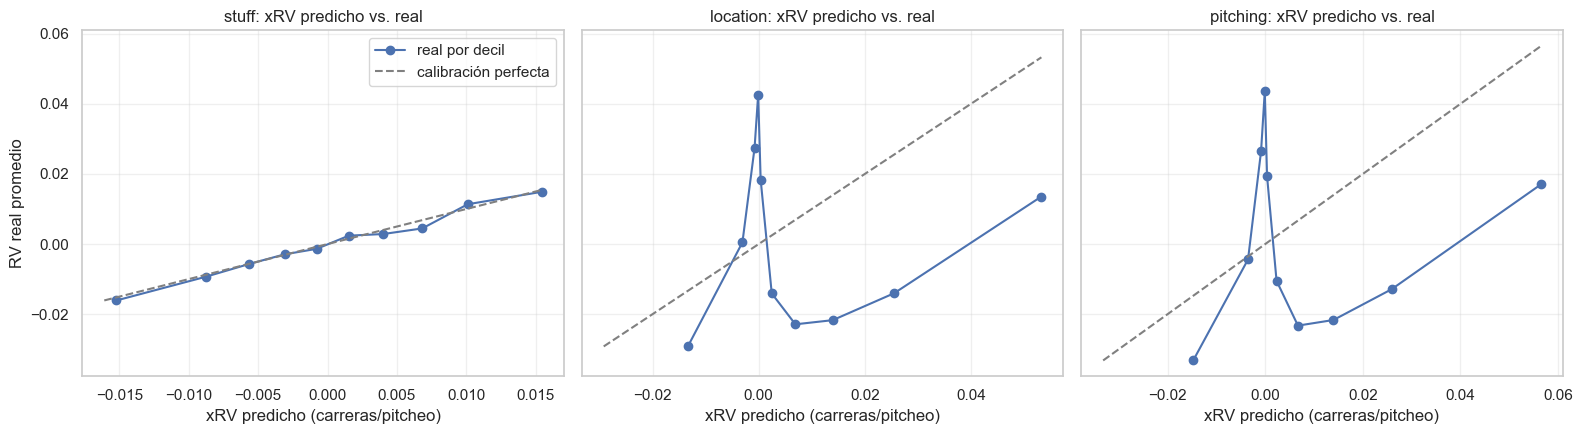

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, capa in zip(axes, VARIABLES):
    col_xrv = f'xrv_{capa}'

    if col_xrv not in d.columns:
        ax.set_title(f'{capa}: xRV no disponible')
        ax.text(0.5, 0.5, f'Columna "{col_xrv}"\nno existe en d',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='red')
        ax.set_xlabel('xRV predicho (carreras/pitcheo)')
        ax.set_ylabel('RV real promedio')
        continue

    # Calcular deciles usando rank (10 grupos del mismo tamaño) — reemplaza pd.qcut
    d_temp = d.with_columns(
        ((pl.col(col_xrv).rank() - 1) * 10 / len(d)).floor().cast(pl.Int32).alias('decil')
    )

    # Agregar xrv medio y rv_pitcheo medio por decil
    t = (
        d_temp.group_by('decil')
        .agg(
            pl.col(col_xrv).mean().alias('xrv'),
            pl.col('rv_pitcheo').mean().alias('real'),
        )
        .sort('decil')
    )

    # Graficar
    ax.plot(t['xrv'].to_numpy(), t['real'].to_numpy(), 'o-', label='real por decil')

    # Línea de calibración perfecta
    xrv_min = t['xrv'].min()
    xrv_max = t['xrv'].max()
    real_min = t['real'].min()
    real_max = t['real'].max()
    lim = [min(xrv_min, real_min), max(xrv_max, real_max)]
    ax.plot(lim, lim, '--', color='gray', label='calibración perfecta')

    ax.set_title(f'{capa}: xRV predicho vs. real')
    ax.set_xlabel('xRV predicho (carreras/pitcheo)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('RV real promedio')
axes[0].legend()
plt.tight_layout()
plt.show()

### 6b. Estabilidad y capacidad predictiva (la prueba que usa FanGraphs)
Un buen Stuff+ debe:
1. **Ser estable:** el Stuff+ de un pitcher en juegos pares se debe parecer al de juegos impares (*split-half*).
2. **Predecir el futuro mejor que el resultado real:** el Stuff+ de 2024 debe predecir las carreras permitidas por pitcheo en 2025 **mejor que las propias carreras de 2024**. Si lo logra, está midiendo habilidad y no suerte.

Usamos pitchers con al menos 300 pitcheos en cada mitad o temporada.

In [28]:
MIN_PITCHEOS = 300
d = d.with_columns(pl.col('rv_pitcheo').alias('rv_pitcher'))  # sin acento
METRICAS_PITCHER = ['stuff_plus', 'location_plus', 'pitching_plus', 'rv_pitcher']

# 1) Split-half: juegos pares vs. impares de cada pitcher-temporada
d = d.with_columns(
    pl.col('game_anon_id').rank('ordinal').over(['pitcher_anon_id', 'year']).alias('numero_juego')
)
d = d.with_columns((pl.col('numero_juego') % 2).alias('mitad'))

mitades = (
    d.group_by(['pitcher_anon_id', 'year', 'mitad'])
    .agg([pl.col(m).mean().alias(m) for m in METRICAS_PITCHER])
)

n_mitad = (
    d.group_by(['pitcher_anon_id', 'year', 'mitad'])
    .agg(pl.col('PitchUID').count().alias('size'))
)

mitades_validas = n_mitad.filter(pl.col('size') >= MIN_PITCHEOS // 2)
mitades_pivot = mitades.join(mitades_validas, on=['pitcher_anon_id', 'year', 'mitad'], how='inner')

estabilidad_data = []
for m in METRICAS_PITCHER:
    m0 = mitades_pivot.filter(pl.col('mitad') == 0).select(['pitcher_anon_id', 'year', m]).rename({m: f'{m}_0'})
    m1 = mitades_pivot.filter(pl.col('mitad') == 1).select(['pitcher_anon_id', 'year', m]).rename({m: f'{m}_1'})
    joined = m0.join(m1, on=['pitcher_anon_id', 'year'], how='inner')
    corr = np.corrcoef(joined[f'{m}_0'].to_numpy(), joined[f'{m}_1'].to_numpy())[0, 1]
    estabilidad_data.append({'metrica': m, 'corr_mitades': corr})

estabilidad = pl.DataFrame(estabilidad_data)

# 2) Año t → año t+1
por_temp = (
    d.group_by(['pitcher_anon_id', 'year'])
    .agg([pl.col(m).mean().alias(m) for m in METRICAS_PITCHER])
)
n_temp = d.group_by(['pitcher_anon_id', 'year']).agg(pl.col('PitchUID').count().alias('size'))
por_temp = por_temp.join(n_temp, on=['pitcher_anon_id', 'year'], how='inner')
por_temp = por_temp.filter(pl.col('size') >= MIN_PITCHEOS)

siguiente = por_temp.with_columns((pl.col('year') + 1).alias('year_sig'))
pares_temp = por_temp.join(siguiente, left_on=['pitcher_anon_id', 'year'], right_on=['pitcher_anon_id', 'year_sig'], how='inner', suffix='_sig')

predictivo_data = []
for m in METRICAS_PITCHER:
    corr = np.corrcoef(pares_temp[m].to_numpy(), pares_temp[f'{m}_sig'].to_numpy())[0, 1]
    predictivo_data.append({'metrica': m, 'corr_con_RV_año_siguiente': corr})

predictivo = pl.DataFrame(predictivo_data)

resultado_est = estabilidad.join(predictivo, on='metrica', how='inner')
print(f"Pitchers en split-half: {len(mitades_pivot.unique(['pitcher_anon_id', 'year']))} | parejas año-a-año: {len(pares_temp)}")
resultado_est = resultado_est.with_columns([pl.col(c).round(3) for c in resultado_est.columns if c != 'metrica'])
resultado_est

Pitchers en split-half: 817 | parejas año-a-año: 245


metrica,corr_mitades,corr_con_RV_año_siguiente
str,f64,f64
"""stuff_plus""",0.992,0.675
"""location_plus""",0.848,0.587
"""pitching_plus""",0.88,0.616
"""rv_pitcher""",0.241,0.189


### 6c. *Season holdout* y calibración por altitud
- **Season holdout:** entrenamos con 2024–2025 y evaluamos en 2026, que el modelo nunca vio.
- **Por altitud** (sustituto del *park holdout*, porque no hay columna de estadio): el xRV promedio predicho debe coincidir con el real en cada nivel de altitud. Si el modelo estuviera mal calibrado en CDMX, aquí se vería.

In [29]:
def season_holdout(capa, anio_prueba=2026):
    """Entrena con las otras temporadas y evalúa en anio_prueba."""
    X = X_dict[capa]  #  numpy array pre-computado
    prueba = np.flatnonzero(d.get_column('year').to_numpy() == anio_prueba)
    entrena = np.flatnonzero(d.get_column('year').to_numpy() != anio_prueba)

    m_res = entrenar_modelo(X, y_res, entrena, 'resultado')
    m_bip = entrenar_modelo(X, y_bip, np.intersect1d(entrena, idx_bip), 'bip')

    prob = m_res.predict_proba(X[prueba])
    xrv = calcular_xrv(capa, prob, m_bip.predict(X[prueba]))
    base = linea_base_prob(por_conteo=(capa != 'stuff'))[prueba]

    return {
        'capa': capa,
        'logloss_modelo': log_loss(y_res[prueba], prob, labels=range(5)),
        'logloss_base': log_loss(y_res[prueba], base, labels=range(5)),
        'corr(xRV, real)': np.corrcoef(xrv, real[prueba])[0, 1]
    }


archivo_sh = os.path.join(CARPETA_MODELOS, "season_holdout.csv")
if REENTRENAR or not os.path.exists(archivo_sh):
    filas_sh = [season_holdout(c) for c in VARIABLES]
    temporada = pl.DataFrame(filas_sh)
    temporada.write_csv(archivo_sh)
else:
    temporada = pl.read_csv(archivo_sh)

temporada = temporada.with_columns(
    (100 * (1 - pl.col('logloss_modelo') / pl.col('logloss_base'))).alias('mejora_logloss_%')
)
print("Season holdout (entrena 2024–2025, prueba 2026):")
cols_r = [c for c in temporada.columns if c != 'capa']
temporada = temporada.with_columns([pl.col(c).round(4) for c in cols_r])
print(temporada)

print("\nCalibración por altitud (xRV promedio predicho vs. real, carreras por 100 pitcheos):")
calib = (
    d.group_by('altitude_category')
    .agg(
        pl.col('rv_pitcheo').count().alias('pitcheos'),
        pl.col('rv_pitcheo').mean().alias('real'),
        *[pl.col(f'xrv_{c}').mean().alias(f'xrv_{c}') for c in VARIABLES]
    )
)

calib_pct = calib.with_columns(
    [(pl.col(f'xrv_{c}') * 100).round(3).alias(f'xrv_{c}') for c in VARIABLES]
).with_columns(
    (pl.col('real') * 100).round(3).alias('real')
)
print(calib_pct)

Season holdout (entrena 2024–2025, prueba 2026):
shape: (3, 5)
┌──────────┬────────────────┬──────────────┬─────────────────┬──────────────────┐
│ capa     ┆ logloss_modelo ┆ logloss_base ┆ corr(xRV, real) ┆ mejora_logloss_% │
│ ---      ┆ ---            ┆ ---          ┆ ---             ┆ ---              │
│ str      ┆ f64            ┆ f64          ┆ f64             ┆ f64              │
╞══════════╪════════════════╪══════════════╪═════════════════╪══════════════════╡
│ stuff    ┆ 1.5045         ┆ 1.5247       ┆ 0.0441          ┆ 1.3273           │
│ location ┆ 1.0188         ┆ 1.4625       ┆ -0.0058         ┆ 30.3389          │
│ pitching ┆ 1.0019         ┆ 1.4625       ┆ 0.0046          ┆ 31.4946          │
└──────────┴────────────────┴──────────────┴─────────────────┴──────────────────┘

Calibración por altitud (xRV promedio predicho vs. real, carreras por 100 pitcheos):
shape: (4, 6)
┌───────────────────┬──────────┬────────┬───────────┬──────────────┬──────────────┐
│ altitude_cate

### 6d. ¿Qué mueve el Stuff+? (valores SHAP)
Para explicarle al pitching coach qué hace bueno a un pitcheo, entrenamos un **modelo explicador**: un XGBoost que imita el xRV de Stuff+ a partir de las mismas variables. Con él calculamos los **valores SHAP**, cuánto suma o resta cada variable al xRV de cada pitcheo, usando `pred_contribs=True` de XGBoost. La importancia de cada variable es el promedio del valor absoluto de su SHAP.

R² del explicador: 0.905


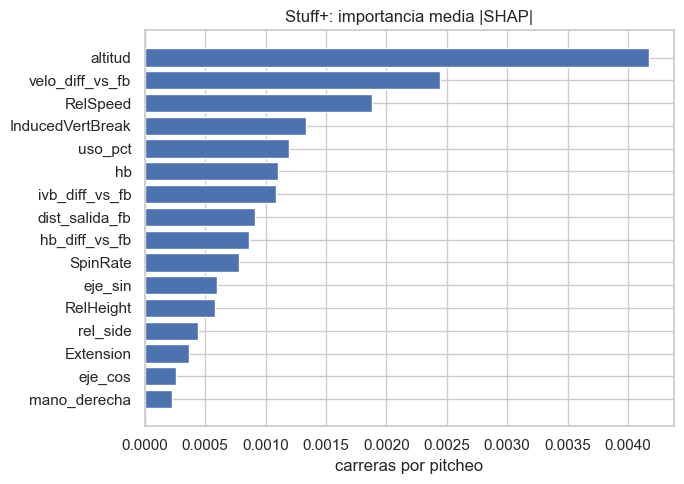

In [30]:
X_stuff = X_dict['stuff']  #  numpy array pre-computado
muestra_idx = np.random.default_rng(SEMILLA).choice(len(d), size=150_000, replace=False)

explicador = xgb.XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, tree_method='hist',
                              max_bin=128, n_jobs=4, random_state=SEMILLA)
explicador.fit(X_stuff[muestra_idx], -d.get_column('xrv_stuff').to_numpy()[muestra_idx])
r2 = explicador.score(X_stuff[muestra_idx], -d.get_column('xrv_stuff').to_numpy()[muestra_idx])
print(f"R² del explicador: {r2:.3f}")

shap = explicador.get_booster().predict(xgb.DMatrix(X_stuff[muestra_idx]), pred_contribs=True)[:, :-1]
importancia_vals = np.abs(shap).mean(axis=0)
importancia_df = pl.DataFrame({'variable': VARIABLES['stuff'], 'importancia': importancia_vals}).sort('importancia')

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importancia_df['variable'].to_list(), importancia_df['importancia'].to_list())
ax.set_title('Stuff+: importancia media |SHAP|')
ax.set_xlabel('carreras por pitcheo')
plt.tight_layout()
plt.show()

## Paso 7: Efecto altitud: el mismo pitcheo en cada nivel

Para responder "¿qué tan bueno sería este pitcheo en CDMX?" no basta con cambiar la variable `altitud`. **La física también cambia:** en altitud el pitcheo se mueve menos. Si solo cambiáramos la etiqueta, estaríamos calificando un pitcheo imposible: el movimiento de nivel del mar en el aire de CDMX.

Por eso hacemos un **contrafactual físicamente consistente**:
1. Con la comparación **emparejada** (mismo pitcher, tipo y temporada) medimos cuánto cambian el IVB y el HB de cada tipo de pitcheo en cada nivel de altitud. Es el análisis de `IdentificadorDePitcheos.ipynb`.
2. Para calificar un pitcheo en otro nivel, **le quitamos el efecto de su altitud real y le sumamos el del nivel nuevo**, en su movimiento y en sus diferencias contra la recta (que también cambia).
3. Cambiamos `altitud` y predecimos con **el mismo modelo del bloque de ese pitcher** (sigue siendo fuera de muestra).
4. Convertimos a escala Plus con **la misma μ y σ** de la liga real, así los números son comparables entre niveles.

Solo se ajustan IVB y HB: la velocidad y el spin casi no cambian en la comparación emparejada (y sus pequeños cambios parecen más de calibración de Trackman que de física).

In [35]:
def cambio_emparejado(col, min_n=15):
    """Cambio promedio de `col` por tipo y nivel de altitud, comparando cada pitcher-temporada-tipo
    contra sí mismo sin altitud. Promedio ponderado por tamaño de muestra."""
    llave = ['pitcher_anon_id', 'year', 'tipo']
    g = d.group_by(llave + ['altitud']).agg(
        pl.col(col).mean().alias('mean'),
        pl.col(col).count().alias('size')
    )
    base = g.filter((pl.col('altitud') == 0) & (pl.col('size') >= min_n))
    salida = {}
    for nivel in (1, 2):
        alt = g.filter((pl.col('altitud') == nivel) & (pl.col('size') >= min_n))
        p = alt.join(base, on=llave, suffix='_base')
        p = p.with_columns(
            (1.0 / (1.0 / pl.col('size') + 1.0 / pl.col('size_base'))).alias('w'),
            (pl.col('mean') - pl.col('mean_base')).alias('delta')
        )
        agg = p.group_by('tipo').agg(
            (pl.col('delta') * pl.col('w')).sum() / pl.col('w').sum()
        )
        salida[nivel] = dict(agg.rows())

    # ✅ Claves como strings: '0', '1', '2'
    filas = []
    for tipo in TIPOS_MODELO:
        filas.append({
            'tipo': tipo,
            '0': 0.0,
            '1': salida[1].get(tipo, None),
            '2': salida[2].get(tipo, None),
        })
    tabla = pl.DataFrame(filas)
    return tabla


DELTA = {
    'InducedVertBreak': cambio_emparejado('InducedVertBreak'),
    'hb': cambio_emparejado('hb')
}
print("Cambio de IVB (pulgadas) por tipo y nivel de altitud:")
print(DELTA['InducedVertBreak'])
print("\nCambio de HB hacia el brazo (pulgadas):")
print(DELTA['hb'])

Cambio de IVB (pulgadas) por tipo y nivel de altitud:
shape: (7, 4)
┌───────────┬─────┬───────────┬───────────┐
│ tipo      ┆ 0   ┆ 1         ┆ 2         │
│ ---       ┆ --- ┆ ---       ┆ ---       │
│ str       ┆ f64 ┆ f64       ┆ f64       │
╞═══════════╪═════╪═══════════╪═══════════╡
│ Four-Seam ┆ 0.0 ┆ -2.777231 ┆ -3.808324 │
│ Sinker    ┆ 0.0 ┆ -1.657777 ┆ -2.190991 │
│ Cutter    ┆ 0.0 ┆ -1.608129 ┆ -2.377974 │
│ Slider    ┆ 0.0 ┆ -0.64116  ┆ -0.744623 │
│ Curveball ┆ 0.0 ┆ 1.235178  ┆ 1.827013  │
│ Changeup  ┆ 0.0 ┆ -1.676953 ┆ -2.04116  │
│ Splitter  ┆ 0.0 ┆ -0.454531 ┆ -0.198346 │
└───────────┴─────┴───────────┴───────────┘

Cambio de HB hacia el brazo (pulgadas):
shape: (7, 4)
┌───────────┬─────┬───────────┬───────────┐
│ tipo      ┆ 0   ┆ 1         ┆ 2         │
│ ---       ┆ --- ┆ ---       ┆ ---       │
│ str       ┆ f64 ┆ f64       ┆ f64       │
╞═══════════╪═════╪═══════════╪═══════════╡
│ Four-Seam ┆ 0.0 ┆ -2.019172 ┆ -2.773227 │
│ Sinker    ┆ 0.0 ┆ -2.83265  ┆ -4.343874

In [38]:
def mover_a_altitud(datos, nivel_nuevo, mover_fisica=True, mover_ambiente=True):
    """Copia de las variables con el pitcheo 'trasladado' a otro nivel de altitud."""
    x = datos.clone()
    if not mover_fisica:
        if mover_ambiente:
            x = x.with_columns(pl.lit(nivel_nuevo).alias('altitud'))
        return x

    tipo_list = x.get_column('tipo').cast(pl.String).to_list()
    fb_list = x.get_column('fb_tipo').cast(pl.String).fill_null('Four-Seam').to_list()
    nivel_real_list = x.get_column('altitud').to_list()

    for col, diff_col in [('InducedVertBreak', 'ivb_diff_vs_fb'), ('hb', 'hb_diff_vs_fb')]:
        tabla = DELTA[col]
        # Construir dict de ajustes: {(tipo, nivel): cambio}
        ajustes = {}
        for row in tabla.iter_rows(named=True):
            t = row['tipo']
            for nivel_col in ['0', '1', '2']:
                if nivel_col in row:
                    ajustes[(t, int(nivel_col))] = row[nivel_col]

        ajuste_pitcheo_vals = []
        ajuste_recta_vals = []
        for i in range(len(x)):
            t = tipo_list[i]
            f = fb_list[i]
            nr = nivel_real_list[i]
            ajuste_pitcheo_vals.append(ajustes.get((t, nivel_nuevo), 0.0) - ajustes.get((t, nr), 0.0))
            ajuste_recta_vals.append(ajustes.get((f, nivel_nuevo), 0.0) - ajustes.get((f, nr), 0.0))

        x = x.with_columns([
            (pl.col(col) + pl.Series(ajuste_pitcheo_vals)).alias(col),
            (pl.col(diff_col) + pl.Series([a - b for a, b in zip(ajuste_pitcheo_vals, ajuste_recta_vals)])).alias(diff_col),
        ])

    if mover_ambiente:
        x = x.with_columns(pl.lit(nivel_nuevo).alias('altitud'))

    return x


def calificar_en_altitud(capa, nivel, **opciones):
    """Plus de cada pitcheo si se hubiera lanzado en `nivel`, con el modelo de su propio bloque."""
    datos = mover_a_altitud(d, nivel, **opciones)

    #  Convertir categóricas a códigos numéricos (igual que X_dict)
    df_temp = datos.select(VARIABLES[capa])
    for var in VARIABLES[capa]:
        if df_temp[var].dtype == pl.Categorical:
            df_temp = df_temp.with_columns(pl.col(var).to_physical().alias(var))
    X = df_temp.to_numpy()

    prob = np.zeros((len(d), len(CLASES)))
    bip = np.zeros(len(d))
    for (m_res, m_bip), (_, prueba) in zip(MODELOS[capa], bloques):
        prob[prueba] = m_res.predict_proba(X[prueba])
        bip[prueba] = m_bip.predict(X[prueba])
    puntaje = -calcular_xrv(capa, prob, bip)

    # Usar ESCALA pre-computada
    escala_df = ESCALA[capa]
    year_vals = d.get_column('year').to_list()
    mu_map = {row['year']: (row['mean'], row['std']) for row in escala_df.iter_rows(named=True)}
    mu = np.array([mu_map[y][0] for y in year_vals])
    sd = np.array([mu_map[y][1] for y in year_vals])

    return 100 + 10 * (puntaje - mu) / sd


NIVELES = {0: 'nivel_mar', 1: 'media', 2: 'cdmx'}
for capa in ['stuff', 'pitching']:
    for nivel, nombre in NIVELES.items():
        d = d.with_columns(pl.Series(f'{capa}_plus_{nombre}', calificar_en_altitud(capa, nivel)))
        print(f"{capa} calificado en {nombre}")

# Descomposición: física de CDMX, ambiente de nivel del mar
nivel_mar = mover_a_altitud(d, 0)
solo_fisica = mover_a_altitud(nivel_mar.with_columns(pl.lit(0).alias('altitud')), 2, mover_ambiente=False)

# Convertir categóricas a códigos numéricos
df_temp = solo_fisica.select(VARIABLES['stuff'])
for var in VARIABLES['stuff']:
    if df_temp[var].dtype == pl.Categorical:
        df_temp = df_temp.with_columns(pl.col(var).to_physical().alias(var))
X = df_temp.to_numpy()

prob, bip = np.zeros((len(d), len(CLASES))), np.zeros(len(d))
for (m_res, m_bip), (_, prueba) in zip(MODELOS['stuff'], bloques):
    prob[prueba] = m_res.predict_proba(X[prueba])
    bip[prueba] = m_bip.predict(X[prueba])

escala_df = ESCALA['stuff']
year_vals = d.get_column('year').to_list()
mu_map = {row['year']: (row['mean'], row['std']) for row in escala_df.iter_rows(named=True)}
mu = np.array([mu_map[y][0] for y in year_vals])
sd = np.array([mu_map[y][1] for y in year_vals])
puntaje = -calcular_xrv('stuff', prob, bip)
d = d.with_columns(pl.Series('stuff_plus_cdmx_solo_fisica', 100 + 10 * (puntaje - mu) / sd))
print("stuff calificado con física de CDMX y ambiente de nivel del mar")

stuff calificado en nivel_mar
stuff calificado en media
stuff calificado en cdmx
pitching calificado en nivel_mar
pitching calificado en media
pitching calificado en cdmx
stuff calificado con física de CDMX y ambiente de nivel del mar


### 7a. Efecto altitud por tipo de pitcheo
Cada pitcheo de la base se califica en los tres niveles. La diferencia **CDMX − nivel del mar** es cuánto Stuff+ pierde (o gana) ese tipo de pitcheo **solo por el aire**, con el mismo pitcher y la misma mecánica.

Y lo **descomponemos** en dos partes:
- **Δ física:** el pitcheo con el movimiento de CDMX, pero en ambiente de nivel del mar. Es lo que se pierde porque el pitcheo se mueve menos.
- **Δ ambiente:** lo que queda. Es el efecto de la altitud sobre el contacto (la bola vuela más y se batea más duro) con el pitcheo ya ajustado.

In [44]:
# Efecto tipo por altitud
efecto_tipo = (
    d.group_by('tipo')
    .agg(
        pl.col('stuff_plus').count().alias('pitcheos'),
        pl.col('stuff_plus_nivel_mar').mean().alias('stuff_nivel_mar'),
        pl.col('stuff_plus_media').mean().alias('stuff_media'),
        pl.col('stuff_plus_cdmx').mean().alias('stuff_cdmx'),
        pl.col('pitching_plus_nivel_mar').mean().alias('pitching_nivel_mar'),
        pl.col('pitching_plus_cdmx').mean().alias('pitching_cdmx'),
    )
)

efecto_tipo = efecto_tipo.with_columns(
    (pl.col('stuff_cdmx') - pl.col('stuff_nivel_mar')).alias('Δ stuff (cdmx − mar)'),
)

solo_fis = (
    d.group_by('tipo')
    .agg(pl.col('stuff_plus_cdmx_solo_fisica').mean().alias('solo_fis'))
)

efecto_tipo = efecto_tipo.join(solo_fis, on='tipo', how='left')

efecto_tipo = efecto_tipo.with_columns(
    (pl.col('solo_fis') - pl.col('stuff_nivel_mar')).alias('  Δ física'),
    (pl.col('stuff_cdmx') - pl.col('solo_fis')).alias('  Δ ambiente'),
    (pl.col('pitching_cdmx') - pl.col('pitching_nivel_mar')).alias('Δ pitching (cdmx − mar)'),
)

efecto_tipo = efecto_tipo.drop('solo_fis').sort('Δ stuff (cdmx − mar)')
print(efecto_tipo)

shape: (7, 11)
┌───────────┬──────────┬─────────────────┬─────────────┬────────────┬────────────────────┬───────────────┬──────────────────────┬────────────┬──────────────┬─────────────────────────┐
│ tipo      ┆ pitcheos ┆ stuff_nivel_mar ┆ stuff_media ┆ stuff_cdmx ┆ pitching_nivel_mar ┆ pitching_cdmx ┆ Δ stuff (cdmx − mar) ┆   Δ física ┆   Δ ambiente ┆ Δ pitching (cdmx − mar) │
│ ---       ┆ ---      ┆ ---             ┆ ---         ┆ ---        ┆ ---                ┆ ---           ┆ ---                  ┆ ---        ┆ ---          ┆ ---                     │
│ cat       ┆ u32      ┆ f64             ┆ f64         ┆ f64        ┆ f64                ┆ f64           ┆ f64                  ┆ f64        ┆ f64          ┆ f64                     │
╞═══════════╪══════════╪═════════════════╪═════════════╪════════════╪════════════════════╪═══════════════╪══════════════════════╪════════════╪══════════════╪═════════════════════════╡
│ Four-Seam ┆ 215261   ┆ 106.819516      ┆ 93.407916   ┆ 91.73904

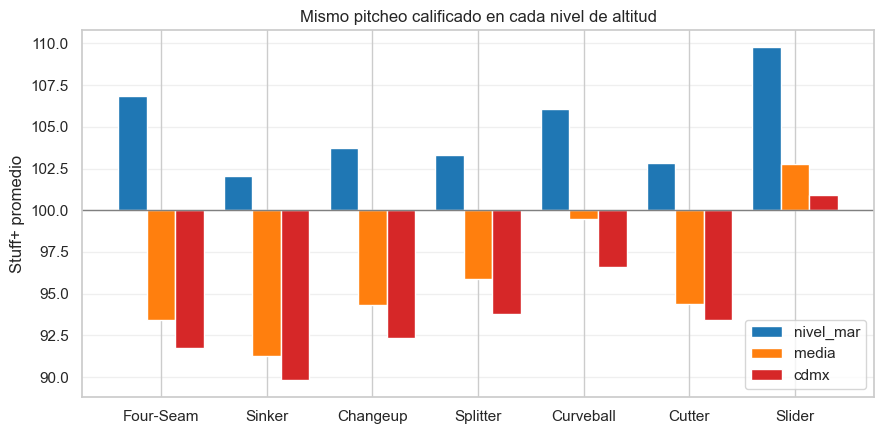

In [45]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# efecto_tipo es un Polars DataFrame, convertir a Pandas para el gráfico
orden = efecto_tipo.sort('Δ stuff (cdmx − mar)')['tipo'].to_list()
x = np.arange(len(orden))

for i, (nombre, color) in enumerate([('nivel_mar', 'tab:blue'), ('media', 'tab:orange'), ('cdmx', 'tab:red')]):
    col_name = f'stuff_{nombre}'
    vals = []
    for t in orden:
        row = efecto_tipo.filter(pl.col('tipo') == t).row(0, named=True)
        vals.append(row[col_name] - 100)
    ax.bar(x + (i - 1) * 0.27, vals, width=0.27, bottom=100, color=color, label=nombre)

ax.axhline(100, color='gray', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(orden)
ax.set_ylabel('Stuff+ promedio')
ax.set_title('Mismo pitcheo calificado en cada nivel de altitud')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 7b. Comprobación con datos observados
El contrafactual es un modelo. Lo contrastamos con lo que **realmente** pasó: el Stuff+ del mismo pitcher-temporada-tipo en juegos de altitud extrema vs. sin altitud (mínimo 15 pitcheos por lado). Si los dos métodos coinciden en dirección y orden, el efecto es robusto.

In [47]:
llave = ['pitcher_anon_id', 'year', 'tipo']

# GroupBy con Polars
g = (
    d.group_by(llave + ['altitud'])
    .agg(
        pl.col('stuff_plus').mean().alias('mean'),
        pl.col('stuff_plus').count().alias('size')
    )
)

# Filtrar altitud 2 (CDMX) y altitud 0 (mar), con mínimo 15 pitcheos
cdmx = g.filter((pl.col('altitud') == 2) & (pl.col('size') >= 15))
mar = g.filter((pl.col('altitud') == 0) & (pl.col('size') >= 15))

# Join emparejado
emp = cdmx.join(mar, on=llave, suffix='_mar')
emp = emp.with_columns(
    (1.0 / (1.0 / pl.col('size') + 1.0 / pl.col('size_mar'))).alias('w'),
    (pl.col('mean') - pl.col('mean_mar')).alias('delta')
)

# Promedio ponderado por tipo
observado = (
    emp.group_by('tipo')
    .agg(
        pl.col('delta').count().alias('pares'),
        ((pl.col('delta') * pl.col('w')).sum() / pl.col('w').sum()).alias('Δ observado')
    )
)

# Agregar Δ contrafactual
observado = observado.join(
    efecto_tipo.select(['tipo', 'Δ stuff (cdmx − mar)']),
    on='tipo', how='left'
)
observado = observado.rename({'Δ stuff (cdmx − mar)': 'Δ contrafactual'})
observado = observado.with_columns([
    pl.col('pares').cast(pl.Float64),
    pl.col('Δ observado').round(1),
    pl.col('Δ contrafactual').round(1)
])
observado

tipo,pares,Δ observado,Δ contrafactual
cat,f64,f64,f64
"""Cutter""",79.0,-9.4,-9.4
"""Four-Seam""",711.0,-15.3,-15.1
"""Changeup""",270.0,-12.2,-11.4
"""Curveball""",169.0,-9.9,-9.5
"""Splitter""",17.0,-10.7,-9.5
"""Slider""",535.0,-9.3,-8.9
"""Sinker""",385.0,-13.5,-12.2


## Paso 8: Agregación y respuestas del entregable

### 8a. Por pitcher-temporada y tipo de pitcheo

**¿Qué columna usar?**
| Columna | Qué significa | Para qué sirve |
|---|---|---|
| `stuff_plus` | calificado donde realmente lanzó | describir lo que pasó |
| `stuff_plus_nivel_mar` | todos sus pitcheos llevados a nivel del mar | **comparar pitchers de forma justa** (neutral al estadio) |
| `stuff_plus_cdmx` | todos sus pitcheos llevados a CDMX | **decidir para Diablos**: cómo rendiría en el Harp Helú |

El 100 es el promedio de todos los pitcheos reales de la liga (mezcla de altitudes). Por eso a nivel del mar el promedio queda arriba de 100 y en CDMX abajo: es el efecto altitud.

Mínimo 50 pitcheos del tipo.

In [50]:
COLS_PLUS = [
    'stuff_plus', 'location_plus', 'pitching_plus',
    'stuff_plus_nivel_mar', 'stuff_plus_cdmx', 'stuff_plus_cdmx_solo_fisica',
    'pitching_plus_nivel_mar', 'pitching_plus_cdmx'
]
COLS_PROB = [f'p_{c}' for c in CLASES]

# GroupBy con Polars
por_pitcher_tipo = (
    d.group_by(['pitcher_anon_id', 'year', 'tipo'])
    .agg(
        pl.col('stuff_plus').count().alias('pitcheos'),
        pl.col('uso_pct').first().alias('uso_pct'),
        pl.col('RelSpeed').mean().alias('velo'),
        pl.col('InducedVertBreak').mean().alias('ivb'),
        pl.col('hb').mean().alias('hb'),
        *[pl.col(c).mean().alias(c) for c in COLS_PLUS + COLS_PROB]
    )
    .filter(pl.col('pitcheos') >= 50)
)

# Δ stuff altitud
por_pitcher_tipo = por_pitcher_tipo.with_columns(
    (pl.col('stuff_plus_cdmx') - pl.col('stuff_plus_nivel_mar')).alias('Δ stuff altitud')
)

# Top 15 por stuff_plus_cdmx
top = por_pitcher_tipo.sort('stuff_plus_cdmx', descending=True).head(15)

# Redondear: 1 decimal para métricas, 3 para probabilidades
# Redondear solo columnas Float64/Float32 automáticamente
float_cols = [c for c in top.columns if top.schema[c] in (pl.Float64, pl.Float32)]
prob_cols = [c for c in float_cols if c in COLS_PROB + ['uso_pct']]
other_float_cols = [c for c in float_cols if c not in COLS_PROB + ['uso_pct']]

top = top.with_columns(
    [pl.col(c).round(1) for c in other_float_cols]
    + [pl.col(c).round(3) for c in prob_cols]
)
top


pitcher_anon_id,year,tipo,pitcheos,uso_pct,velo,ivb,hb,stuff_plus,location_plus,pitching_plus,stuff_plus_nivel_mar,stuff_plus_cdmx,stuff_plus_cdmx_solo_fisica,pitching_plus_nivel_mar,pitching_plus_cdmx,p_bola,p_strike_cantado,p_whiff,p_foul,p_en_juego,Δ stuff altitud
str,i32,cat,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f32,f32,f32,f32,f64
"""pitcher_00469""",2026,"""Slider""",123,0.433,87.0,-7.4,-5.8,122.4,82.6,91.1,122.6,122.9,121.7,100.5,98.6,0.311,0.166,0.261,0.127,0.135,0.3
"""pitcher_00130""",2025,"""Slider""",350,0.364,82.5,-3.9,-14.0,118.4,84.4,87.8,119.5,117.8,119.4,99.9,97.6,0.332,0.155,0.181,0.169,0.164,-1.7
"""pitcher_01078""",2026,"""Slider""",109,0.335,85.6,4.3,-11.4,120.3,89.2,93.7,120.4,116.9,120.4,101.3,98.0,0.38,0.127,0.244,0.137,0.112,-3.5
"""pitcher_00212""",2026,"""Four-Seam""",67,0.705,96.5,21.9,6.6,130.8,89.0,98.2,130.8,116.4,123.9,103.3,98.5,0.286,0.132,0.269,0.207,0.106,-14.4
"""pitcher_00548""",2025,"""Slider""",292,0.54,81.2,-0.8,-17.3,118.4,88.5,93.6,119.7,116.4,118.8,102.2,98.1,0.264,0.219,0.182,0.17,0.165,-3.3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""pitcher_01025""",2025,"""Slider""",62,0.193,87.8,-0.0,-7.1,115.4,83.1,87.5,117.3,113.1,116.9,99.8,97.4,0.342,0.139,0.222,0.153,0.144,-4.1
"""pitcher_00407""",2026,"""Slider""",145,0.474,87.5,1.3,-2.7,115.6,88.1,90.3,120.1,113.0,119.0,101.7,98.7,0.347,0.145,0.208,0.142,0.158,-7.1
"""pitcher_00920""",2025,"""Slider""",55,0.286,84.3,-6.2,0.0,114.6,84.7,87.3,114.8,113.0,115.3,99.0,97.4,0.261,0.208,0.24,0.134,0.156,-1.8


### 8b. Por pitcher-temporada
Promedio de todos sus pitcheos (ponderado por uso, porque cada pitcheo cuenta una vez). Mínimo 300 pitcheos. **`Δ stuff altitud`** indica qué tanto le afecta lanzar en CDMX: los más negativos son los más afectados y los cercanos a 0 los más consistentes.

In [49]:
por_pitcher = (
    d.group_by(['pitcher_anon_id', 'year'])
    .agg(
        pl.col('stuff_plus').count().alias('pitcheos'),
        pl.col('PitcherThrows').first().alias('mano'),
        *[pl.col(c).mean().alias(c) for c in COLS_PLUS]
    )
    .filter(pl.col('pitcheos') >= 300)
)

por_pitcher = por_pitcher.with_columns(
    (pl.col('stuff_plus_cdmx') - pl.col('stuff_plus_nivel_mar')).alias('Δ stuff altitud')
)

print("Mejor Stuff+ calificado en CDMX:")
print(por_pitcher.sort('stuff_plus_cdmx', descending=True).head(10))

print("\nMás afectados por la altitud:")
print(por_pitcher.sort('Δ stuff altitud').head(10))

print("\nMás consistentes (menor pérdida):")
print(por_pitcher.sort('Δ stuff altitud', descending=True).head(10))

Mejor Stuff+ calificado en CDMX:
shape: (10, 13)
┌─────────────────┬──────┬──────────┬───────┬────────────┬───────────────┬───────────────┬──────────────────────┬─────────────────┬─────────────────────────────┬─────────────────────────┬────────────────────┬─────────────────┐
│ pitcher_anon_id ┆ year ┆ pitcheos ┆ mano  ┆ stuff_plus ┆ location_plus ┆ pitching_plus ┆ stuff_plus_nivel_mar ┆ stuff_plus_cdmx ┆ stuff_plus_cdmx_solo_fisica ┆ pitching_plus_nivel_mar ┆ pitching_plus_cdmx ┆ Δ stuff altitud │
│ ---             ┆ ---  ┆ ---      ┆ ---   ┆ ---        ┆ ---           ┆ ---           ┆ ---                  ┆ ---             ┆ ---                         ┆ ---                     ┆ ---                ┆ ---             │
│ str             ┆ i32  ┆ u32      ┆ str   ┆ f64        ┆ f64           ┆ f64           ┆ f64                  ┆ f64             ┆ f64                         ┆ f64                     ┆ f64                ┆ f64             │
╞═════════════════╪══════╪══════════╪══════

### 8c. ¿Qué arsenal produce el Stuff+ más alto en CDMX?
**Arsenal** = combinación de tipos que el pitcher usa al menos 10% del tiempo (por ejemplo "Four-Seam + Slider + Changeup"). Para cada arsenal promediamos el Stuff+ **calificado en CDMX** de los pitchers que lo usan. Solo arsenales con al menos 8 pitcher-temporadas.

In [54]:
USO_MINIMO = 0.10

# Filtrar por uso mínimo
uso = por_pitcher_tipo.filter(pl.col('uso_pct') >= USO_MINIMO)

# Obtener tipos por pitcher-temporada, casteando a String primero
tipos_por_pt = (
    uso.select(['pitcher_anon_id', 'year', 'tipo'])
    .with_columns(pl.col('tipo').cast(pl.String))  # ✅ Cast to String
    .group_by(['pitcher_anon_id', 'year'])
    .agg(pl.col('tipo').sort().alias('tipos_lista'))
)

# Concatenar tipos con ' + '
tipos_por_pt = tipos_por_pt.with_columns(
    pl.col('tipos_lista').list.join(' + ').alias('arsenal')
).select(['pitcher_anon_id', 'year', 'arsenal'])

# Unir con por_pitcher
por_pitcher = por_pitcher.join(tipos_por_pt, on=['pitcher_anon_id', 'year'], how='left')

# Agrupar por arsenal
por_arsenal = (
    por_pitcher.filter(pl.col('arsenal').is_not_null())
    .group_by('arsenal')
    .agg(
        pl.col('stuff_plus').count().alias('pitcher_temporadas'),
        pl.col('stuff_plus_cdmx').mean().alias('stuff_cdmx'),
        pl.col('stuff_plus_nivel_mar').mean().alias('stuff_nivel_mar'),
        pl.col('pitching_plus_cdmx').mean().alias('pitching_cdmx'),
    )
    .filter(pl.col('pitcher_temporadas') >= 8)
)

por_arsenal = por_arsenal.with_columns(
    (pl.col('stuff_cdmx') - pl.col('stuff_nivel_mar')).alias('Δ stuff altitud')
)

por_arsenal.sort('stuff_cdmx', descending=True)

arsenal,pitcher_temporadas,stuff_cdmx,stuff_nivel_mar,pitching_cdmx,Δ stuff altitud
str,u32,f64,f64,f64,f64
"""Four-Seam + Slider""",94,96.757596,109.284903,98.406852,-12.527307
"""Cutter + Four-Seam + Slider""",33,96.097275,107.023087,97.756334,-10.925812
"""Sinker + Slider""",43,96.085407,107.78803,98.267253,-11.702623
"""Curveball + Four-Seam""",16,95.736963,109.95335,97.8757,-14.216387
"""Four-Seam + Sinker + Slider""",110,95.552605,107.006199,98.16701,-11.453594
…,…,…,…,…,…
"""Changeup + Sinker""",14,92.467425,105.646955,96.919991,-13.179529
"""Changeup + Four-Seam""",14,91.549489,105.005785,97.050321,-13.456296
"""Changeup + Cutter + Four-Seam …",12,91.432321,102.930612,96.784289,-11.498291


### 8d. Exportar resultados
- `resultados/stuff_plus_por_pitcheo.pkl`: cada pitcheo con sus tres Plus, las probabilidades y los contrafactuales de altitud (pickle, porque son 600 mil renglones).
- `resultados/*.csv`: tablas por pitcher-tipo, por pitcher, por arsenal y efecto por tipo, listas para Excel o para el dashboard.

In [55]:
# Columnas para exportar
cols_pitcheo = (
    ['PitchUID', 'year', 'game_anon_id', 'pitcher_anon_id', 'tipo', 'altitude_category',
     'Balls', 'Strikes', 'RelSpeed', 'InducedVertBreak', 'hb', 'loc_x', 'PlateLocHeight',
     'xrv_stuff', 'xrv_location', 'xrv_pitching', 'rv_pitcheo']
    + COLS_PLUS + COLS_PROB
)

# Filtrar solo columnas que existen en d
cols_existentes = [c for c in cols_pitcheo if c in d.columns]

# Exportar pitcheos (usar parquet en lugar de pickle para Polars)
d.select(cols_existentes).write_parquet(
    os.path.join(CARPETA_RESULTADOS, "stuff_plus_por_pitcheo.parquet")
)

# Exportar tablas agregadas como CSV
por_pitcher_tipo.write_csv(
    os.path.join(CARPETA_RESULTADOS, "stuff_plus_por_pitcher_tipo.csv")
)
por_pitcher.write_csv(
    os.path.join(CARPETA_RESULTADOS, "stuff_plus_por_pitcher.csv")
)
por_arsenal.write_csv(
    os.path.join(CARPETA_RESULTADOS, "stuff_plus_por_arsenal.csv")
)
efecto_tipo.write_csv(
    os.path.join(CARPETA_RESULTADOS, "efecto_altitud_por_tipo.csv")
)

print("Archivos en resultados/:", sorted(os.listdir(CARPETA_RESULTADOS)))

Archivos en resultados/: ['efecto_altitud_por_tipo.csv', 'stuff_plus_por_arsenal.csv', 'stuff_plus_por_pitcheo.parquet', 'stuff_plus_por_pitcher.csv', 'stuff_plus_por_pitcher_tipo.csv']
